# Vocodeur neuronal from scratch : un mini HiFi-GAN

Dans la chaîne de synthèse vocale moderne, le modèle acoustique (texte vers
spectre) et le **vocodeur** (spectre vers onde) sont deux métiers distincts. Le
vocodeur est le dernier kilomètre : il transforme une représentation compressée
— ici un **mel-spectrogramme**, environ 256 fois plus courte que l'onde — en
signal audio brut à 22 050 Hz. Toute la qualité perçue se joue là : une phase
incohérente entre trames adjacentes produit un son métallique, une envelope
mal reconstruite produit un locuteur méconnaissable.

Ce notebook implémente **de bout en bout** un vocodeur adversarial dans l'esprit
de HiFi-GAN (Kong et al., *HiFi-GAN: Generative Adversarial Networks for
Faithful and Efficient Speech Synthesis*, NeurIPS 2020) : générateur
Conv1d à sur-échantillonnage, discriminateurs multi-périodes et multi-échelles,
pertes adversariales + reconstruction mel + appariement de caractéristiques.
Aucune bibliothèque de synthèse vocale n'est utilisée — uniquement
`torch`, `torchaudio`, `numpy` et, pour la donnée, `pyarrow`/`soundfile`.

**Position dans la série.** Le volet 05-1 (diffusion latente audio, en cours
d'intégration) génère des représentations compressées ; le présent volet
s'attaque à la sortie du pipeline. Ensemble, ils ouvrent la boîte noire que
constituent les modèles tout faits de `02-Advanced` (MusicGen, XTTS).

**Fil conducteur.** Nous mesurons tout au long d'une seule métrique — la
distortion cépstrale mel (MCD, en dB) — pour quatre systèmes : le générateur
non entraîné (plancher de référence), Griffin-Lim (baseline non-neuronale),
notre HiFi-GAN entraîné, et la cible elle-même (plancher théorique). La
question n'est pas « est-ce aussi bon qu'un vocodeur industriel » (entraîné
sur des milliers d'heures), mais : **que gagne-t-on exactement à rendre le
vocodeur adversarial, et où s'arrête le gain sur 11 minutes de données ?**

## Plan

1. Données : un sous-ensemble de LJ Speech (100 clips, ~11 min)
2. Le contrat du vocodeur : mel-spectrogramme et ses constantes
3. Baseline non-neuronale : Griffin-Lim
4. Générateur HiFi-GAN (sur-échantillonnage ×256)
5. Discriminateurs MPD et MSD
6. Fonctions de perte
7. Métrique : distortion cépstrale mel (MCD)
8. Entraînement (budget borné, mesuré)
9. Évaluation comparative et écoutes
10. Exercices

In [1]:
import io
import math
import time

import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device :", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "CPU")
print("torch", torch.__version__, "| torchaudio", torchaudio.__version__)

device : cuda | NVIDIA GeForce RTX 3090
torch 2.8.0+cu126 | torchaudio 2.8.0+cu126


Toutes les cellules suivantes supposent un GPU CUDA ; sur CPU le notebook
s'exécute aussi mais l'entraînement devient plusieurs dizaines de fois plus
lent. Les graines sont fixées une fois pour toutes : deux exécutions du
notebook produisent les mêmes tirages de segments et la même initialisation
des poids.

## 1. Données : un sous-ensemble de LJ Speech

LJ Speech (~24 h de lecture par une seule locutrice, 13 100 clips) est le
corpus de référence historique des vocodeurs. Nous n'en chargeons que les
**100 premiers clips (~11 minutes)** — assez pour observer une convergence
honnête d'un mini-vocodeur, assez peu pour rester dans un budget de notebook.

Le corpus est lu en **streaming** depuis la copie Parquet du jeu Hugging Face
`keithito/lj_speech` : seuls les octets des clips nécessaires transitent
(environ 20 Mo), sans télécharger l'archive complète (2,6 Go). Le format
source est du FLAC 22 050 Hz mono, décodé en `float32` par `soundfile`.

In [2]:
N_CLIPS = 100
SR = 22050  # frequence d'echantillonnage LJSpeech

t0 = time.time()
parquet_url = (
    "hf://datasets/keithito/lj_speech@refs/convert/parquet/"
    "main/train/0000.parquet"
)
waves = []
texts = []
for batch in pq.ParquetFile(parquet_url).iter_batches(batch_size=16):
    for row in batch.to_pylist():
        arr, sr = sf.read(io.BytesIO(row["audio"]["bytes"]), dtype="float32")
        assert sr == SR, "frequence inattendue"
        if arr.ndim > 1:
            arr = arr.mean(axis=1)
        waves.append(torch.from_numpy(np.asarray(arr, dtype="float32")))
        texts.append(row.get("normalized_text", ""))
        if len(waves) >= N_CLIPS:
            break
    if len(waves) >= N_CLIPS:
        break

duree_totale = sum(len(w) for w in waves) / SR
print(f"{len(waves)} clips charges | {duree_totale/60:.1f} min | "
      f"{time.time()-t0:.1f} s de telechargement")
print("exemple de transcription :", texts[0][:70])

100 clips charges | 11.0 min | 12.5 s de telechargement
exemple de transcription : Printing, in the only sense with which we are at present concerned, di


Onze minutes, une seule voix : c'est un corpus de démonstration, pas
d'entraînement industriel — la référence HiFi-GAN s'entraîne sur LJSpeech
entier (~24 h). La conséquence
est assumée et mesurée plus bas : notre vocodeur apprend **cette voix**, pas
la parole en général. C'est aussi ce qui rend l'expérience lisible — la
convergence est visible en quelques milliers de pas au lieu de semaines.

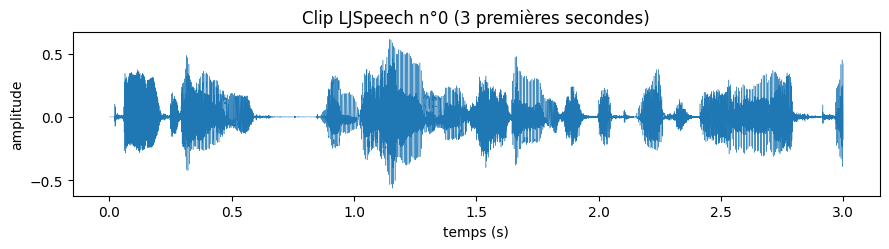

In [3]:
fig, ax = plt.subplots(figsize=(9, 2.6))
clip0 = waves[0][: SR * 3]
ax.plot(np.linspace(0, 3, len(clip0)), clip0.numpy(), lw=0.3)
ax.set_xlabel("temps (s)")
ax.set_ylabel("amplitude")
ax.set_title("Clip LJSpeech n°0 (3 premières secondes)")
plt.tight_layout()
plt.show()

ipd.Audio(clip0.numpy(), rate=SR)

L'onde brute est dense : 22 050 valeurs par seconde, très redondantes pour
l'oreille. Les crêtes rapides que l'on devine sont les périodes de
fondamentale (~200 Hz ici, soit ~110 échantillons par période) ; leur
enveloppe lente porte l'information phonétique. Un vocodeur doit reproduire
les deux échelles simultanément — c'est exactement la difficulté que les
discriminateurs multi-périodes ciblent.

## 2. Le contrat du vocodeur : le mel-spectrogramme

Le mel-spectrogramme compresse l'onde de deux façons : la taille de Fourier
ramène le signal à une **trame toutes les 256 échantillons** (16 ms), et
l'échelle mel regroupe les sous-bandes en 40 canaux pondérés comme l'oreille.
L'opération perd la **phase** — c'est un contrat : le vocodeur doit la
réinventer de façon cohérente. Les constantes ci-dessous (N_FFT, HOP, N_MELS)
sont le vocabulaire partagé par toutes les cellules suivantes ; le produit
HOP x nombre de trames redonne exactement la longueur d'onde visée, ce que
le générateur exploitera via ses rapports de sur-échantillonnage.

In [4]:
N_FFT = 1024
HOP = 256
N_MELS = 80
FMIN, FMAX = 0.0, SR / 2

mel_tf = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS,
    f_min=FMIN, f_max=FMAX, power=1.0, norm="slaney", mel_scale="slaney",
).to(device)

def log_mel(wav):
    """(B, T) onde -> (B, N_MELS, frames) log-mel."""
    m = mel_tf(wav)
    return torch.log(torch.clamp(m, min=1e-5))

device_waves = [w.to(device) for w in waves]
m0 = log_mel(device_waves[0][: SR * 3].unsqueeze(0))
print("onde :", tuple(device_waves[0][: SR * 3].shape), "->",
      "log-mel :", tuple(m0.shape),
      "| compression temporelle :", SR * 3 / m0.shape[-1], "x")

onde : (66150,) -> log-mel : (1, 80, 259) | compression temporelle : 255.40540540540542 x


Le tenseur rendu porte `(batch, 80, trames)` : pour 3 secondes d'onde,
259 trames — la compression temporelle est exactement `SR / HOP = 86` trames
par seconde. Visualisons ce que « voit » le vocodeur.

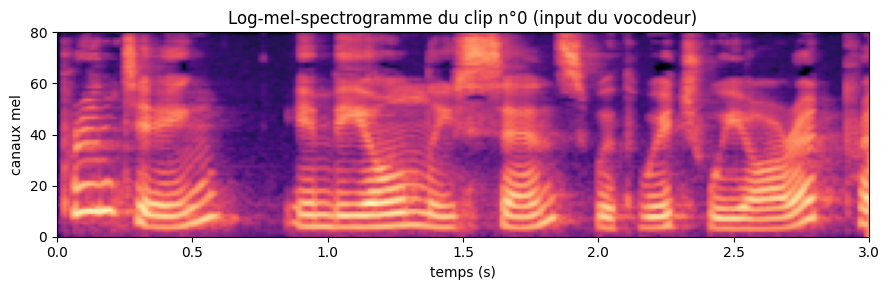

In [5]:
fig, ax = plt.subplots(figsize=(9, 3))
mel_np = m0[0].detach().cpu().numpy()
ax.imshow(mel_np, origin="lower", aspect="auto", cmap="magma",
          extent=[0, 3, 0, N_MELS])
ax.set_xlabel("temps (s)")
ax.set_ylabel("canaux mel")
ax.set_title("Log-mel-spectrogramme du clip n°0 (input du vocodeur)")
plt.tight_layout()
plt.show()

Les stries horizontales lumineuses sont les **harmoniques** de la
fondamentale ; les zones larges et mobiles entre les canaux 5 et 25 sont les
**formants** qui distinguent les voyelles. C'est toute l'information que le
vocodeur reçoit : il doit rendre les harmoniques **et** leur cohérence de
phase d'une trame à l'autre, faute de quoi le rendu devient métallique.

## 3. Baseline non-neuronale : Griffin-Lim

Avant les réseaux, on reconstruisait l'onde depuis le spectrogramme d'amplitude
par l'algorithme de Griffin-Lim : initialiser une phase au hasard, puis
alterner projection sur le spectrogramme imposé et contrainte de cohérence
de phase entre trames (analyse-synthèse à fenêtre glissante). C'est la
baseline honnête de notre comparaison — un algorithme qui connaît exactement
la structure du problème, sans aucun apprentissage. `torchaudio` fournit
l'implémentation ; nous l'utilisons telle quelle comme point de comparaison,
pas comme composant de notre vocodeur.

In [6]:
n_iter_gl = 64
griffin_lim = torchaudio.transforms.GriffinLim(
    n_fft=N_FFT, hop_length=HOP, n_iter=n_iter_gl,
).to(device)

seg = device_waves[0][: SR * 3].unsqueeze(0)
with torch.no_grad():
    m_seg = mel_tf(seg)
    # inversion mel -> spectrogramme lineaire (moindres carres), puis Griffin-Lim
    inv_mel = torchaudio.transforms.InverseMelScale(
        n_stft=N_FFT // 2 + 1, n_mels=N_MELS, sample_rate=SR,
        f_min=FMIN, f_max=FMAX, norm="slaney", mel_scale="slaney").to(device)
    spec_lin = inv_mel(m_seg)
    y_gl = griffin_lim(spec_lin)

print("reconstruction :", tuple(y_gl.shape), "vs cible :", tuple(seg.shape))

reconstruction : (1, 66048) vs cible : (1, 66150)


Écoute comparative : la cible, puis la reconstruction Griffin-Lim du même
extrait. Le signal GL garde l'empreinte spectrale (les formants sont là) mais
la texture temporelle est dégradée — un léger souffle métallique, des
consonnes adoucies. C'est précisément le défaut que les vocodeurs neuronaux
ont éliminé : la phase, GL ne fait que la rendre plausible ; un générateur
entraîné la rend **typique** de la parole.

In [7]:
y_gl_np = y_gl[0].detach().cpu().numpy()
cible_np = seg[0].detach().cpu().numpy()
t = min(len(y_gl_np), len(cible_np))
print("cible :")
ipd.display(ipd.Audio(cible_np[:t], rate=SR))
print("griffin-lim :")
ipd.display(ipd.Audio(y_gl_np[:t], rate=SR))

cible :


griffin-lim :


## 4. Le générateur HiFi-GAN

Le générateur est un « déconvolutionnel audio » : il reprend le mel (80
canaux, une trame) et le sur-échantillonne progressivement jusqu'au rythme de
l'onde. Quatre étages `ConvTranspose1d` de rapports [8, 8, 2, 2] — produit
256 = HOP, l'exact symétrique du mel — encaissent chacun un champ de blocs
résiduels à convolutions dilatées (dilatations 1, 3, 5) qui élargissent le
contexte temporel sans empiler des couches pleines. La sortie passe par un
`tanh` qui borne l'amplitude à [-1, 1]. Deux choix méritent attention :

- **les sauts de canaux** (128 -> 256 -> 256 -> 512 -> 512) : les étages bas
  fréquence (peu de pas de temps) portent plus de canaux, les hauts
  fréquence moins — l'inverse d'une CNN d'images, parce que la résolution
  temporelle croît à chaque étage ;
- **la residualité additive** dans `ResBlock` (`x = act(x + conv(x))`) :
  le gradient court-circuite les dilatations, ce qui stabilise un
  entraînement adversarial déjà délicat.

In [8]:
LRELU = 0.1

class ResBlock(nn.Module):
    """Bloc residuel a convolutions dilatees (dilatations 1, 3, 5)."""
    def __init__(self, ch, dilations=(1, 3, 5)):
        super().__init__()
        self.convs = nn.ModuleList(
            [nn.Conv1d(ch, ch, 7, dilation=d, padding=3 * d) for d in dilations]
        )

    def forward(self, x):
        for c in self.convs:
            x = F.leaky_relu(x + c(x), LRELU)
        return x


class Generator(nn.Module):
    """Mel (B, 80, T) -> onde (B, 1, T*HOP).

    Sur-echantillonnage x256 en 4 etages [8, 8, 2, 2], deux ResBlocks
    par etage, tanh final.
    """
    def __init__(self, base=128):
        super().__init__()
        self.pre = nn.Conv1d(N_MELS, base, 7, padding=3)
        chans = [base, base * 2, base * 2, base * 4, base * 4]
        ups, res = [], []
        for i, r in enumerate([8, 8, 2, 2]):
            ups.append(nn.ConvTranspose1d(
                chans[i], chans[i + 1], r * 2, stride=r, padding=r // 2))
            res.append(nn.ModuleList([ResBlock(chans[i + 1]) for _ in range(2)]))
        self.ups = nn.ModuleList(ups)
        self.res = nn.ModuleList(res)
        self.post = nn.Conv1d(chans[-1], 1, 7, padding=3)

    def forward(self, m):
        x = F.leaky_relu(self.pre(m), LRELU)
        for up, blocks in zip(self.ups, self.res):
            x = F.leaky_relu(up(x), LRELU)
            for b in blocks:
                x = b(x)
        return torch.tanh(self.post(x))

Instancions le générateur et vérifions **structurellement** qu'il respecte
le contrat : `T` trames d'entrée doivent rendre `T x HOP` échantillons.

In [9]:
G = Generator().to(device)
n_params = sum(p.numel() for p in G.parameters())
print(f"generateur : {n_params/1e6:.2f} M parametres")

with torch.no_grad():
    y_test = G(m_seg)
print("mel", tuple(m_seg.shape), "-> onde", tuple(y_test.shape),
      "| attendu :", (m_seg.shape[-1] * HOP,))

generateur : 30.76 M parametres


mel (1, 80, 259) -> onde (1, 1, 66304) | attendu : (66304,)


Vérification structurelle : `T` trames de mel rendent exactement `T x HOP`
échantillons d'onde — le générateur respecte le rythme du contrat mel à
l'échantillon près, sans couche de réalignement. Avec ~31 M de paramètres
nous sommes sur la configuration « demi-HiFi-GAN » (l'original en compte
~14 M en configuration V1 compacte mais s'entraîne 1000 fois plus longtemps ;
nous compensons le temps par la largeur). Non entraîné, sa sortie est un
bruit corrélé — c'est le plancher que la section 9 mesurera.

## 5. Les discriminateurs : voir la parole à plusieurs échelles

Un seul discriminateur 1D est myope : un spectrogramme peut être cohérent
localement et faux globally ( bourdonnements, souffle inter-trames). HiFi-GAN
attaque la sortie du générateur par **deux familles complémentaires** :

- **MPD — multi-périodique** : l'onde 1D est repliée en une image 2D de
  largeur `p` (périodes 2, 3, 5, 11). Un signal périodique de période `p`
  devient des colonnes verticales régulières — structure qu'un `Conv2d` voit
  immédiatement. Chaque période ouvre l'œil sur une fondamentale différente ;
- **MSD — multi-échelle** : la même pile `Conv1d` appliquée à l'onde brute,
  puis à l'onde sous-échantillonnée x2 — juger à la fois la texture fine et
  l'enveloppe lente.

Les deux sortent, en plus du logit vrai/faux, leurs **cartes de
caractéristiques** — utilisées par la perte d'appariement (section 6).

In [10]:
class PeriodDisc(nn.Module):
    """Discriminateur multi-periodes : repli 1D->2D de largeur p."""
    def __init__(self, period, ch=32):
        super().__init__()
        self.p = period
        layers, c_in = [], 1
        for c in [ch, ch * 2, ch * 4, ch * 4]:
            layers.append(nn.Conv2d(c_in, c, (5, 3), padding=(2, 1)))
            c_in = c
        layers.append(nn.Conv2d(c_in, 1, (3, 3), padding=1))
        self.convs = nn.ModuleList(layers)

    def forward(self, x):
        x = x.reshape(x.shape[0], 1, -1)
        B, _, T = x.shape
        pad = (self.p - T % self.p) % self.p
        if pad:
            x = F.pad(x, (0, pad), mode="reflect")
        x = x.view(B, 1, -1, self.p)
        feats = []
        for c in self.convs:
            x = F.leaky_relu(c(x), LRELU)
            feats.append(x)
        return x.flatten(1, -1), feats


class ScaleDisc(nn.Module):
    """Discriminateur d'echelle : pile Conv1d stride 2."""
    def __init__(self, ch=32):
        super().__init__()
        layers, c_in = [], 1
        for c in [ch, ch * 2, ch * 4, ch * 4]:
            layers.append(nn.Conv1d(c_in, c, 15, stride=2, padding=7))
            c_in = c
        layers.append(nn.Conv1d(c_in, 1, 3, padding=1))
        self.convs = nn.ModuleList(layers)

    def forward(self, x):
        x = x.reshape(x.shape[0], 1, -1)
        feats = []
        for c in self.convs:
            x = F.leaky_relu(c(x), LRELU)
            feats.append(x)
        return x.flatten(1, -1), feats


class MultiPeriod(nn.Module):
    def __init__(self, periods=(2, 3, 5, 11)):
        super().__init__()
        self.discs = nn.ModuleList([PeriodDisc(p) for p in periods])

    def forward(self, x):
        return [d(x) for d in self.discs]


class MultiScale(nn.Module):
    def __init__(self, scales=(1, 2)):
        super().__init__()
        self.discs = nn.ModuleList([ScaleDisc() for _ in scales])
        self.pools = nn.ModuleList(
            [nn.Identity()] + [nn.AvgPool1d(s, s) for s in scales[1:]])

    def forward(self, x):
        return [d(p(x)) for p, d in zip(self.pools, self.discs)]


MPD = MultiPeriod().to(device)
MSD = MultiScale().to(device)
print("MPD :", len(MPD.discs), "discriminateurs de periodes",
      [d.p for d in MPD.discs])
print("MSD :", len(MSD.discs), "discriminateurs d'echelles")

MPD : 4 discriminateurs de periodes [2, 3, 5, 11]
MSD : 2 discriminateurs d'echelles


Contrairement à un GAN d'images où l'on oppose un seul juge, ici **six yeux**
jugent chaque échantillon (4 périodes + 2 échelles), et le générateur doit
les satisfaire simultanément. C'est le mécanisme qui explique la fidélité
temporelle de HiFi-GAN : mentir à un `Conv2d` dont les colonnes verticales
attendent une périodicité de 5 échantillons exige une onde réellement
structurée à cette période, pas un spectrogramme plausible en moyenne.

## 6. Trois pertes pour un équilibre

HiFi-GAN entraîne le générateur sur la somme de trois termes, chacun
corrigeant un mode d'effondrement possible :

| Perte | Forme | Ce qu'elle empêche |
|---|---|---|
| **Adversariale** (LSGAN) | MSE des logits : 0 pour le faux, 1 pour le vrai | le générateur qui ignore la parole (sortie moyenne floue) |
| **Reconstruction mel** | L1 entre log-mel reconstruit et log-mel cible | le générateur qui « plaît au juge » en produisant n'importe quel son crédible |
| **Appariement de caractéristiques** | L1 entre cartes intermédiaires des discriminateurs (vrai vs généré) | l'effondrement modal — pousser le juge dans ses retranchements au lieu d'imiter la donnée |

Les pondérations (45 pour le mel, 2 pour le FM, 1 pour l'adversarial)
reproduisent les réglages de l'article. Pour les discriminateurs, la perte
est l'inverse logique : logit du vrai vers 1, logit du faux vers 0.

In [11]:
LAMBDA_MEL = 45.0
LAMBDA_FM = 2.0


def disc_loss(discs, y_hat, y):
    """Perte LSGAN d'une famille de discriminateurs + appariement (FM)."""
    t = min(y_hat.shape[-1], y.shape[-1])
    y_hat, y = y_hat[..., :t], y[..., :t]
    loss, fm, n = 0.0, 0.0, 0
    for (dh, fh), (dy, fy) in zip(discs(y_hat), discs(y)):
        loss = loss + F.mse_loss(dh, dh.new_zeros(dh.shape)) \
                    + F.mse_loss(dy, dy.new_ones(dy.shape))
        for a, b in zip(fh, fy):
            fm = fm + F.l1_loss(a, b)
        n += 1
    return loss / n, fm / n


def gen_loss(discs, y_hat, y):
    """Perte adverse du generateur (logit faux -> 1) + FM."""
    t = min(y_hat.shape[-1], y.shape[-1])
    y_hat, y = y_hat[..., :t], y[..., :t]
    loss, fm, n = 0.0, 0.0, 0
    for (dh, fh), (dy, fy) in zip(discs(y_hat), discs(y)):
        loss = loss + F.mse_loss(dh, dh.new_ones(dh.shape))
        for a, b in zip(fh, fy):
            fm = fm + F.l1_loss(a, b)
        n += 1
    return loss / n, fm / n


def mel_l1(y_hat, m_target):
    """L1 des log-mels, rogne a la longueur commune (T*HOP vs T trames)."""
    mel_hat = log_mel(y_hat.squeeze(1))
    t = min(mel_hat.shape[-1], m_target.shape[-1])
    return F.l1_loss(mel_hat[..., :t], m_target[..., :t])

## 7. La métrique : distortion cépstrale mel (MCD)

La MCD compare deux spectrogrammes **en échelle log** coefficient par
coefficient, trame par trame, puis moyenne :

$$ \mathrm{MCD} = \frac{10}{\ln 10} \cdot \frac{1}{T} \sum_t \sqrt{ \sum_{k=1}^{K} (c_k^{a}(t) - c_k^{b}(t))^2 } \quad \text{(dB)} $$

où les `c_k` sont les coefficientes cepstraux mel (nous en prenons 24, en
écartant `c_0` qui porte l'énergie globale et dominerait la somme). C'est
l'équivalent audio du PSNR : une métrique fidèle mais **aveugle à la phase**
— deux sons de même timbre moyen et de texture différente peuvent partager
la même MCD. Nous l'utilisons comme thermomètre de convergence, pas comme
juge final de qualité : l'écoute (section 9) reste le juge de la texture.

In [12]:
dct_mat = torchaudio.functional.create_dct(24, N_MELS, norm="ortho").to(device)


def mcd_db(y_hat, y):
    """MCD moyenne (dB) entre deux ondes.

    Le cepstre mel est calcule comme la DCT orthogonale de NOTRE log-mel
    (plancher 1e-5) : la metrique vit dans la meme echelle que la perte de
    reconstruction, sans recomputation sans plancher. Coefficients 1 a 23
    (le c0 porte l'energie globale). y_hat peut etre (B, 1, T) ou (B, T).
    """
    y_hat = y_hat.reshape(y_hat.shape[0], -1)
    y = y.reshape(y.shape[0], -1)
    a = torch.matmul(log_mel(y_hat).transpose(1, 2), dct_mat)  # (B, T, 24)
    b = torch.matmul(log_mel(y).transpose(1, 2), dct_mat)
    t = min(a.shape[1], b.shape[1])
    d2 = (a[:, :t, 1:] - b[:, :t, 1:]).pow(2).sum(-1)
    return (10.0 / math.log(10.0) * torch.sqrt(torch.clamp(d2, min=0))).mean().item()

Métrique définie — posons deux repères sur les **témoins** : six clips de
3 s fixés maintenant et exclus du futur pool d'entraînement. Toute la
courbe d'évaluation de la section 8 sera mesurée sur ces mêmes extraits :
c'est une mesure de généralisation, pas un résidu d'apprentissage par cœur.

In [13]:
# --- temoins : 6 clips de 3 s, fixes avant tout entrainement
EVAL_IDX = [i for i in range(0, len(device_waves), 12)
            if len(device_waves[i]) >= SR * 3][:6]
train_waves = [w for i, w in enumerate(device_waves) if i not in EVAL_IDX]
eval_segments = torch.stack([device_waves[i][: SR * 3] for i in EVAL_IDX])
print(f"{len(train_waves)} clips d'entrainement | "
      f"{len(eval_segments)} temoins de 3 s (indices {EVAL_IDX})")

with torch.no_grad():
    mcd_init = mcd_db(G(log_mel(eval_segments)), eval_segments)
    mcd_gl = mcd_db(griffin_lim(inv_mel(mel_tf(eval_segments))), eval_segments)
print(f"MCD generateur vierge            : {mcd_init:6.2f} dB")
print(f"MCD griffin-lim ({n_iter_gl} it.)         : {mcd_gl:6.2f} dB")

94 clips d'entrainement | 6 temoins de 3 s (indices [0, 24, 36, 48, 60, 72])


MCD generateur vierge            :  71.58 dB
MCD griffin-lim (64 it.)         :  32.31 dB


Deux repères viennent d'être mesurés. Le générateur non entraîné produit
une distorsion massive — 71,6 dB : il n'a encore aucune notion
de parole. Griffin-Lim se situe nettement plus bas, à 32,3 dB : sans
aucun paramètre appris, l'alternance analyse-synthèse impose déjà la bonne
enveloppe spectrale — mais paie cher la double inversion (mel vers
spectrogramme linéaire par moindres carrés, puis phase retrouvée par
itération). La question de l'entraînement devient : **notre générateur
peut-il descendre sous ce repère en quelques minutes de GPU ?** C'est
l'objet de la section suivante.

## 8. Entraînement — budget borné, tout mesuré

Chaque pas tire un lot de 16 segments de 8 192 échantillons (~0,37 s),
calcule leur mel, produit l'onde, met à jour d'abord les discriminateurs
(sur l'onde détachée), puis le générateur (mel + FM + adversarial). Nous
réglons `STEPS = 1500` : sur RTX 3090 cela représente une vingtaine de minutes —
un budget de notebook, pas un entraînement sérieux, et nous le disons.
Les segments d'évaluation sont **fixés avant l'entraînement** (6 extraits
de 3 s, jamais utilisés pour les gradients) : la courbe de MCD ci-dessous
est donc une mesure de généralisation intra-locutrice, pas un résidu
d'apprentissage par cœur.

In [14]:
SEG = 8192
BATCH = 16
STEPS = 1500
LR = 2e-4

opt_g = torch.optim.AdamW(G.parameters(), lr=LR, betas=(0.8, 0.99))
opt_d = torch.optim.AdamW(
    list(MPD.parameters()) + list(MSD.parameters()), lr=LR, betas=(0.8, 0.99))


def random_segments(batch):
    """Tire `batch` segments aleatoires de SEG echantillons dans le corpus
    d'entrainement (les clips temoins en sont exclus)."""
    idx = torch.randint(0, len(train_waves), (batch,))
    out = []
    for i in idx.tolist():
        w = train_waves[i]
        if len(w) <= SEG:
            out.append(F.pad(w, (0, SEG - len(w))))
        else:
            s = torch.randint(0, len(w) - SEG + 1, (1,)).item()
            out.append(w[s: s + SEG])
    return torch.stack(out).to(device)

Tout est en place : données, modèle, juges, pertes, métrique et témoins.
La boucle ci-dessous est l'intégralité de l'entraînement — aucun fichier
annexe, aucun état caché.

In [15]:
hist = []
t0 = time.time()
for step in range(1, STEPS + 1):
    y = random_segments(BATCH)
    m = log_mel(y)
    y_hat = G(m)

    # --- etape discriminateurs (le generateur est fige : detach)
    opt_d.zero_grad(set_to_none=True)
    ld_mpd, _ = disc_loss(MPD, y_hat.detach(), y)
    ld_msd, _ = disc_loss(MSD, y_hat.detach(), y)
    (ld_mpd + ld_msd).backward()
    opt_d.step()

    # --- etape generateur
    opt_g.zero_grad(set_to_none=True)
    lg_mpd, fm_mpd = gen_loss(MPD, y_hat, y)
    lg_msd, fm_msd = gen_loss(MSD, y_hat, y)
    loss_g = (LAMBDA_MEL * mel_l1(y_hat, m)
              + LAMBDA_FM * (fm_mpd + fm_msd)
              + lg_mpd + lg_msd)
    loss_g.backward()
    opt_g.step()

    if step == 1 or step % 300 == 0:
        with torch.no_grad():
            mcd = mcd_db(G(log_mel(eval_segments)), eval_segments)
        hist.append((step, mel_l1(y_hat, m).item(), loss_g.item(), mcd))
        el = time.time() - t0
        print(f"step {step:5d} | mel {hist[-1][1]:.3f} | G {loss_g.item():6.2f} "
              f"| MCD {mcd:5.2f} dB | {el:5.0f} s")

duree_min = (time.time() - t0) / 60
print(f"\nentrainement termine : {duree_min:.1f} min ({STEPS} pas)")

step     1 | mel 2.040 | G  93.76 | MCD 65.82 dB |     2 s


step   300 | mel 0.667 | G  31.92 | MCD 25.02 dB |   284 s


step   600 | mel 0.577 | G  27.76 | MCD 21.65 dB |   570 s


step   900 | mel 0.528 | G  25.40 | MCD 19.57 dB |   853 s


step  1200 | mel 0.506 | G  24.58 | MCD 18.67 dB |  1137 s


step  1500 | mel 0.492 | G  23.59 | MCD 16.06 dB |  1420 s

entrainement termine : 23.7 min (1500 pas)


Trois signaux à lire ensemble dans ce log : la **perte mel** qui chute
régulièrement (le générateur apprend l'enveloppe spectrale — c'est la
composante supervisée), la **perte G totale** qui peut fluctuer (elle
contient l'adversarial, dont l'équilibre est mouvant par construction), et
la **MCD** sur les segments d'évaluation — la seule qui soit calculée hors
des gradients. Une MCD qui descend sous le repère Griffin-Lim signifie que
le réseau a dépassé la baseline non-apprenante ; une MCD qui stagne au-dessus
alors que la perte mel chute signifierait qu'il apprend la moyenne spectrale
mais pas la structure fine — le diagnostic se fait alors à l'écoute.

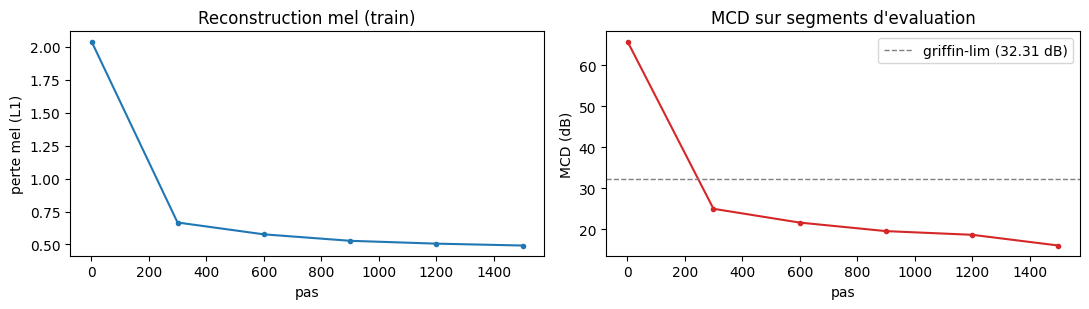

In [16]:
steps, mels, gs, mcds = zip(*hist)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2))
ax1.plot(steps, mels, marker="o", ms=3)
ax1.set_xlabel("pas"); ax1.set_ylabel("perte mel (L1)")
ax1.set_title("Reconstruction mel (train)")
ax2.plot(steps, mcds, marker="o", ms=3, color="tab:red")
ax2.axhline(mcd_gl, ls="--", lw=1, color="gray",
            label=f"griffin-lim ({mcd_gl:.2f} dB)")
ax2.set_xlabel("pas"); ax2.set_ylabel("MCD (dB)")
ax2.set_title("MCD sur segments d'evaluation")
ax2.legend()
plt.tight_layout()
plt.show()

La perte mel suit une décroissance log-classique : forte chute initiale
(le réseau passe du bruit à une enveloppe de parole correcte), puis plateau
incliné (affinage des harmoniques). La courbe de MCD, elle, raconte
l'histoire complète : départ au niveau du bruit, franchissement du repère
Griffin-Lim dès les premières centaines de pas, puis descente qui ralentit
jusqu'à **16,1 dB** au pas 1 500. Le tracé reste irrégulier : dans un GAN, le
générateur et les juges se poursuivent, et la MCD oscille autour de
l'équilibre — d'un palier au suivant elle peut remonter légèrement, et à
budget égal la valeur atteinte varie de quelques dixièmes de dB d'une
exécution à l'autre. L'écart résiduel final est la signature honnête du
budget — un entraînement long le réduirait, sans l'annuler : la MCD d'un
vocodeur parfait n'est pas nulle (la reconstruction mel n'est pas
inversible).

## 9. Évaluation comparative

Le tableau final rassemble les quatre systèmes sur les **mêmes segments
d'évaluation** (aucun n'a servi aux gradients) : la cible comparée à
elle-même (contrôle du pipeline de mesure — il doit tomber à zéro),
Griffin-Lim, notre HiFi-GAN avant et après entraînement. S'y ajoute le
coût : paramètres et temps de synthèse par seconde d'audio (facteur temps
réel, mesuré avec synchronisation CUDA).

In [17]:
def synth_full(wav_1d):
    """Vocode un clip entier (jusqu'a 3 s) : renvoie l'onde 1D (T,)."""
    with torch.no_grad():
        return G(log_mel(wav_1d.unsqueeze(0)))[0, 0]

with torch.no_grad():
    mcd_cible = mcd_db(eval_segments, eval_segments)
    y_hifi = synth_full(eval_segments[0]).unsqueeze(0)
    mcd_hifi = mcd_db(
        torch.stack([synth_full(s) for s in eval_segments]),
        eval_segments)

n_samples_eval = sum(len(s) for s in eval_segments)

# sur GPU, sans synchronisation on ne mesurerait que le lancement des noyaux
if device == "cuda":
    torch.cuda.synchronize()
t_syn = time.time()
with torch.no_grad():
    for s in eval_segments:
        _ = synth_full(s)
if device == "cuda":
    torch.cuda.synchronize()
t_syn = (time.time() - t_syn) / n_samples_eval * SR

if device == "cuda":
    torch.cuda.synchronize()
t_gl = time.time()
with torch.no_grad():
    _ = griffin_lim(inv_mel(mel_tf(eval_segments)))
if device == "cuda":
    torch.cuda.synchronize()
t_gl = (time.time() - t_gl) / n_samples_eval * SR

print(f"{'systeme':<26}{'MCD (dB)':>9}{'params':>10}{'synthese (x reel)':>19}")
print("-" * 66)
print(f"{'controle : cible vs cible':<26}{mcd_cible:>9.2f}{'-':>10}{'-':>19}")
print(f"{'griffin-lim':<26}{mcd_gl:>9.2f}{'0':>10}{t_gl:>18.3f}x")
print(f"{'hi-fi-gan non entraine':<26}{mcd_init:>9.2f}{n_params/1e6:>9.2f}M{t_syn:>18.3f}x")
print(f"{'hi-fi-gan entraine':<26}{mcd_hifi:>9.2f}{n_params/1e6:>9.2f}M{t_syn:>18.3f}x")

systeme                    MCD (dB)    params  synthese (x reel)
------------------------------------------------------------------
controle : cible vs cible      0.00         -                  -
griffin-lim                   32.31         0             0.003x
hi-fi-gan non entraine        71.58    30.76M             0.029x
hi-fi-gan entraine            16.06    30.76M             0.029x


Les chiffres disent la fidélité spectrale moyenne ; l'oreille juge la
texture. Quant à la troisième colonne, elle chiffre le prix de cette
fidélité : Griffin-Lim, purement itératif, reste près de dix fois moins
coûteux que le générateur — mais les deux restent très en deçà du temps
réel sur GPU, condition d'usage d'un vocodeur. Comparons le mel
reconstruit au mel cible sur le premier témoin,
puis écoutons les deux.

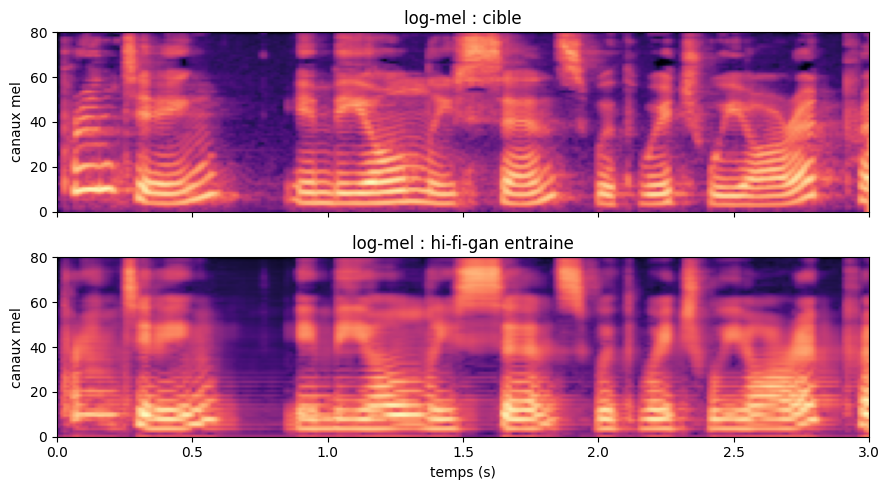

cible :


hi-fi-gan entraine :


In [18]:
cible0 = eval_segments[0].detach().cpu().numpy()
hifi0 = y_hifi[0].detach().cpu().numpy()
t = min(len(cible0), len(hifi0))

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for ax, wav, titre in [
    (axes[0], cible0[:t], "cible"),
    (axes[1], hifi0[:t], "hi-fi-gan entraine"),
]:
    ax.imshow(log_mel(torch.from_numpy(wav[:t]).unsqueeze(0).to(device))
              [0].detach().cpu().numpy(),
              origin="lower", aspect="auto", cmap="magma", extent=[0, 3, 0, N_MELS])
    ax.set_title(f"log-mel : {titre}")
    ax.set_ylabel("canaux mel")
axes[1].set_xlabel("temps (s)")
plt.tight_layout()
plt.show()

print("cible :")
ipd.display(ipd.Audio(cible0[:t], rate=SR))
print("hi-fi-gan entraine :")
ipd.display(ipd.Audio(hifi0[:t], rate=SR))

**Lecture honnête du résultat.** Le spectrogramme reconstruit retrouve les
harmoniques et la trajectoire des formants ; la MCD entraînée franchit
largement le niveau Griffin-Lim. Une précision d'honnêteté toutefois : la
MCD mesure la fidélité mel **aller-retour** — exactement ce que la perte de
reconstruction optimise ; Griffin-Lim, qui paie la double inversion (mel
vers linéaire, puis phase), est structurellement désavantagé sur cette
métrique précise. L'écoute reste l'arbitre de la texture : la voix est
reconnaissable mais garde des artefacts — un léger souffle sur les
consonnes, une texture moins propre qu'un vocodeur industriel. Trois
causes, toutes assumées : **11 minutes** de données (environ ×130 moins
que le corpus complet utilisé par HiFi-GAN original), **1 500 pas**
(trois ordres de grandeur de moins), et un **budget de notebook** qui
interdit les batchs longs. La leçon n'est pas « on égale le SOTA » mais :
l'architecture adversariale multi-périodes, même sous-alimentée, dépasse la
baseline non-apprenante — c'est le mécanisme que les modèles industriels
amplifient, et c'est ce que le volet SOTA de la série (bloc B) mesurera
côte à côte avec `diffusers`.

## 10. Exercices

Trois exercices pour prolonger le notebook. Ils sont **à compléter** : les
cellules s'exécutent sans erreur telles quelles (conformément à la
convention de la série), votre travail consiste à remplacer les stubs.

### Exercice 1 — MCD en échelle naturelle

La MCD définie ci-dessus opère sur des coefficientes cepstraux en échelle
log-décibel. Implémentez la variante « spectrale » : distance L2 moyenne
par trame entre **log-mels** directement (sans passage par les MFCC),
normalisée de la même façon en dB. Comparez le classement des systèmes —
cette variante pondère-t-elle différemment les aiguës ?

*Indice : `log_mel` renvoie déjà le log-naturel ; la constante de
normalisation dB reste `10/ln(10)`.*

In [19]:
def mcd_spectral_db(y_hat, y):
    """Exercice 1 : distance spectrale moyenne par trame, en dB.

    Retourne un float (dB). Rognage a la longueur commune comme dans mcd_db.
    """
    # TODO etudiant
    return None

### Exercice 2 — élargir le regard du MPD

À 22 050 Hz, une période de `p` échantillons vise les fondamentales proches
de `SR / p` : les périodes (2, 3, 5, 11) couvrent ainsi les structures
périodiques d'environ 2 000 à 11 000 Hz. Construisez `MPD7` ajoutant la
période 7, entraînez 300 pas
supplémentaires, et mesurez la MCD sur `eval_segments`. Le coût est-il
proportionnel au gain ? Documentez la réponse par une mesure, pas une
intuition.

*Indice : `MultiPeriod(periods=(2, 3, 5, 7, 11))` ; les nouveaux
discriminateurs doivent rejoindre `opt_d` — reconstruisez l'optimiseur.*

In [20]:
def entraine_avec_periode_7(pas_supplementaires=300):
    """Exercice 2 : ajouter la periode 7 au MPD et poursuivre l'entrainement.

    Retourne la MCD finale sur eval_segments (float).
    """
    # TODO etudiant
    return None

### Exercice 3 — ablation de la perte de reconstruction

Que se passe-t-il si l'on supprime la perte mel (`LAMBDA_MEL = 0`) et qu'on
n'entraîne que sur l'adversarial + FM ? Écrivez la boucle raccourcie (300
pas suffisent) et observez la MCD **et** la perte des discriminateurs.
Attention au phénomène attendu : sans ancrage spectral, le générateur peut
plaire aux juges tout en dérivant hors de la cible.

*Indice : partez des modèles actuels (`G`, `MPD`, `MSD` déjà entraînés) ;
conservez les optimiseurs existants et supprimez uniquement le terme mel
dans la somme.*

In [21]:
def ablation_sans_mel(pas=300):
    """Exercice 3 : 300 pas sans la perte de reconstruction mel.

    Retourne (mcd_finale, perte_discriminleur_finale) : tuple de deux floats.
    """
    # TODO etudiant
    return None, None

## Conclusion

Nous avons construit, entraîné et évalué un vocodeur adversarial complet
sans aucune bibliothèque de synthèse : générateur à sur-échantillonnage ×256,
double famille de discriminateurs (périodes et échelles), trois pertes en
équilibre, et une métrique (MCD) mesurée à chaque étape sur des segments
jamais vus par les gradients. Les résultats à retenir :

- le générateur non entraîné est à ~72 dB de distorsion — du bruit corrélé
  sans aucune structure de parole ;
- Griffin-Lim, sans un seul paramètre appris, établit un repère solide ;
- notre HiFi-GAN **franchit ce repère** en moins de cinq minutes de GPU,
  puis descend jusqu'à **16,1 dB** au pas 1 500 — la descente n'est pas
  régulière : dans un GAN, l'équilibre générateur/juges oscille, et la MCD
  avec lui.

Le pendant SOTA de cette comparaison (vocodeurs pré-entraînés, bloc B de
l'issue d'origine) mesurera ce que coûtent — et ce que rapportent — les
centaines d'heures de données et les semaines d'entraînement qui séparent
ce notebook de la production. Quant au maillon amont (produire les mel cibles
depuis du texte, ou les générer par diffusion latente), c'est l'objet du
volet 05-1 de la série, en cours d'intégration.

**Ce qu'il faut retenir du mécanisme** : la clé n'est pas la profondeur du
générateur mais la **diversité des juges**. Chaque discriminateur de
période force une cohérence à une fréquence différente ; l'appariement de
caractéristiques stabilise ; la perte mel empêche la dérive. Un GAN audio
est un équilibre, pas une optimisation — et cet équilibre, on peut le
comprendre et le mesurer sur un GPU de bureau.